# Phase 0: Scoping & Question Definition

## Analysis Brief

The question this project answers is whether my music taste over the past four years has been something I actively chose or something increasingly handed to me by Spotify's algorithm. 

The hypothesis is that as my listening volume and reliance on the app have grown, the share of streams I deliberately started has declined while autoplay/algorithmic streams have taken over a larger share of my listening and that artists I discovered passively (via autoplay or recommendation) churn out of my rotation faster than artists I sought out myself, because passive discovery reflects the algorithm's confidence in a track more than my own investment in it. 

A "good" so-what outcome would be a clear divergence - for example, deliberately discovered artists surviving 2–3x longer in my rotation than algorithm-discovered ones which would argue that intentional discovery builds real attachment, a finding relevant well beyond music (it's the same logic as organic vs. paid-acquisition customer retention). A "bad"  but equally interesting outcome would be no meaningful difference between the two groups, or even algorithm-discovered artists retaining better, which would suggest passive curation is just as sticky as active choice, undercutting the assumption that intentionality drives loyalty, and would be its own compelling (if less flattering) story about how much curation actually decides for me.

## Intentionality

Before writing any code, I need to define what comprises intentionality. 

Likely deliberate reason_start values. All these require an action aimed at a specific track :

    - clickrow (selecting a specific track from a list or queue) 
    - playbtn (resuming from a dead stop)
    - backbtn (going back to replay something on purpose) 

Likely passive/algorithmic values. These describe the app continuing or resuming without a specific choice:

    -  trackdone (the previous track ended and this one started without input)
    -  appload (playback began on app open)

Does shuffle=True downgrade an otherwise-deliberate start? 

- My working position is no, for clickrow and playbtn specifically, if I reached in and picked a track while shuffle was running that's arguably an override of the algorithm, not a submission to it. Shuffle should only matter for disambiguating fwdbtn, not for discounting clearer intent signals. I want to stay open to being wrong here once I see how often this actually happens.

Does an early skip override a deliberate start into a rejection? 

- My hypothesis is yes starting a track deliberately but abandoning it within seconds reflects a choice that didn't hold up, not sustained intent. I don't yet know what threshold (a fixed time floor vs. a percentage of track length) will cleanly separate "gave it a real chance" from "immediate regret," so I'll treat the exact cutoff as something to tune empirically.

What I'm explicitly not deciding yet: the exact numeric thresholds (ms_played floor, skip-time cutoff) and the final weighting scheme for a composite score. Phase 0 is for defining the logic, not the thresholds .. those depend on seeing the actual distributions and picking them before that would mean reverse-engineering my definitions to fit numbers I haven't looked at yet, which is backwards.



## Defining Sessions

Gap threshold: 30 minutes of inactivity ends a session (this is what Google Analytics says is default for web browsing, lets apply to music listnening too). Long enough to survive a short pause, short enough not to merge separate sittings. ==Will revisit if EDA shows gaps clustering near 25–35 min.==

## Artist rotation / churn

**Enters rotation**: more than one play, not just a single stream

**Abandoned**: no plays for 90+ days after being active. Will sanity-check against my own natural replay gaps before trusting this.

Build as a cohort table: group artists by month first heard, track % of each cohort still active at 1/3/6/12 months — same shape as subscription retention, artists as "customers."

## Core Metrics

1. % deliberate vs. passive streams by month/quarter — headline trend
2. Artist cohort retention curves, split by discovery method (deliberate vs. passive first listen) — the key comparison
3. Skip rate by position in session (early vs. late) — attentiveness over a sitting
4. Skip rate by shuffle state — supports/tests the passive-listening assumption

### Idea - enrich with spotify API 
### Idea - nfc tag that returns "This day on spotify" kind of like snapchat this day in history 

# Phase 1: Data Understanding Pre-EDA

Spotify Extended Streaming History Fields

| Field | Description |
|--------|-------------|
| `ts` | Timestamp indicating when the track stopped playing in UTC (Coordinated Universal Time). Format: Year, month, day, followed by a military-time timestamp. |
| `username` | Your Spotify username. |
| `platform` | The platform used when streaming the track (e.g., Android OS, Google Chromecast). |
| `ms_played` | The number of milliseconds the track was played. |
| `conn_country` | The two-letter country code where the stream was played (e.g., `SE` for Sweden). |
| `ip_addr_decrypted` | The IP address logged while streaming the track. |
| `user_agent_decrypted` | The user agent used during streaming (e.g., Mozilla Firefox, Safari). |
| `master_metadata_track_name` | The name of the track. |
| `master_metadata_album_artist_name` | The name of the artist, band, or podcast creator. |
| `master_metadata_album_album_name` | The name of the album containing the track. |
| `spotify_track_uri` | A unique Spotify Track URI in the format `spotify:track:<base-62 string>`. This URI can be used to locate the track within Spotify. |
| `episode_name` | The name of the podcast episode. |
| `episode_show_name` | The name of the podcast show. |
| `spotify_episode_uri` | A unique Spotify Episode URI in the format `spotify:episode:<base-62 string>`. This URI can be used to locate the episode within Spotify. |
| `reason_start` | The reason playback started (e.g., `trackdone`). |
| `reason_end` | The reason playback ended (e.g., `endplay`). |
| `shuffle` | Boolean (`True` or `False`) indicating whether shuffle mode was enabled. |
| `skipped` | Boolean indicating whether the track was skipped before finishing. |
| `offline` | Boolean indicating whether the track was played in offline mode. |
| `offline_timestamp` | Timestamp indicating when offline mode was used, if applicable. |
| `incognito_mode` | Boolean indicating whether the track was played during a private session. |

## Bring Data into Dataframe

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
# before anything, I want to load the data into a big df
# we can do this by writing a function that parses the folder, reads each json to a df, and concats all the dfs together
def json_to_df(folder_path):
    folder = Path(folder_path)
    
    temp_dfs = [] # empty list

    for file in folder.glob("*.json"):
        df = pd.read_json(file)
        temp_dfs.append(df)
        #for every file in the folder w/ filetype json, read it and append it to the list 

    if temp_dfs: #if list has values
        return pd.concat(temp_dfs, ignore_index=True)
        #pd.concat on a list stacks them vertically, ignore_index=True discards the original indexing and replaces it with a fresh 0 to n-1 index  
    else:
        return pd.DataFrame() #else return empty dataframe 


In [3]:
data = json_to_df('/Users/medhasubramaniyan/Desktop/GitHub_Repos/spotify-listening-analysis/Spotify Extended Streaming History')
data

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode
0,2024-07-27T16:52:10Z,ios,790,US,2607:fb91:1848:f35:8d7:8676:731e:d9fa,Golmaal,Anushka Manchanda,Golmaal Returns,spotify:track:3ZG4yg79MNFjW1reNwvcEb,None,...,NaN,NaN,NaN,playbtn,endplay,False,True,0.0,1.722099e+09,False
1,2024-07-27T16:56:59Z,ios,289280,US,2607:fb91:1848:f35:8d7:8676:731e:d9fa,Rehja Re,Javed Ali,Golmaal Fun Unlimited,spotify:track:0bNRJP5ohcR6CAy6b2u2S9,None,...,NaN,NaN,NaN,clickrow,endplay,False,True,0.0,1.722099e+09,False
2,2024-07-27T16:57:06Z,ios,7040,US,2607:fb91:1848:f35:8d7:8676:731e:d9fa,Golmaal,Anushka Manchanda,Golmaal Returns,spotify:track:3ZG4yg79MNFjW1reNwvcEb,None,...,NaN,NaN,NaN,clickrow,endplay,False,True,0.0,1.722099e+09,False
3,2024-07-27T16:58:30Z,ios,83770,US,2607:fb91:1848:f35:8d7:8676:731e:d9fa,Guzarish,Javed Ali,Ghajini,spotify:track:2MvCNH9ua0CeOgUQfZf56z,None,...,NaN,NaN,NaN,clickrow,endplay,True,True,0.0,1.722099e+09,False
4,2024-07-27T16:59:10Z,ios,36040,US,2607:fb91:1848:f35:8d7:8676:731e:d9fa,Usure Pogudhey,A.R. Rahman,Raavanan (Original Motion Picture Soundtrack),spotify:track:5jOi67yXzjpMdl6KFNWSIe,None,...,NaN,NaN,NaN,clickrow,endplay,True,True,0.0,1.722100e+09,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185325,2025-03-08T22:06:39Z,ios,141919,US,2607:fb91:1804:98d:6c81:4213:77b5:bb21,I'm The Reason,Drakeo the Ruler,I'm The Reason,spotify:track:42mlQGXfoz6mEfoAA5ptJP,None,...,None,None,None,trackdone,fwdbtn,True,True,0.0,1.741471e+09,False
185326,2025-03-08T22:06:40Z,ios,1230,US,2607:fb91:1804:98d:6c81:4213:77b5:bb21,Love/Hate,Millyz,Love/Hate,spotify:track:7s535w6NXxctKFuA2nMmjc,None,...,None,None,None,fwdbtn,fwdbtn,True,True,0.0,1.741472e+09,False
185327,2025-03-08T22:10:55Z,ios,254830,US,2607:fb91:1804:98d:6c81:4213:77b5:bb21,Houstatlantaville (feat. Lil Baby & Travis Scott),EST Gee,I Aint Feeling You,spotify:track:6LjUHEO9mdsGGxnss3oAb1,None,...,None,None,None,fwdbtn,fwdbtn,True,True,0.0,1.741472e+09,False
185328,2025-03-08T22:10:56Z,ios,840,US,2607:fb91:1804:98d:6c81:4213:77b5:bb21,MF GROOVE (with Ravyn Lenae),Smino,NOIR,spotify:track:3f0wlG15mXf22WOraAYwJ7,None,...,None,None,None,fwdbtn,fwdbtn,True,True,0.0,1.741472e+09,False


## Data Quality and Shape

In [4]:
data.info() #vast majority of columns are of type object
data.shape #185,330 rows, 23 columns
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185330 entries, 0 to 185329
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   ts                                 185330 non-null  object 
 1   platform                           185330 non-null  object 
 2   ms_played                          185330 non-null  int64  
 3   conn_country                       185330 non-null  object 
 4   ip_addr                            185330 non-null  object 
 5   master_metadata_track_name         184805 non-null  object 
 6   master_metadata_album_artist_name  184805 non-null  object 
 7   master_metadata_album_album_name   184805 non-null  object 
 8   spotify_track_uri                  184805 non-null  object 
 9   episode_name                       517 non-null     object 
 10  episode_show_name                  517 non-null     object 
 11  spotify_episode_uri                517 

,ms_played,offline_timestamp
count,1.853300e+05,1.492040e+05
mean,8.961796e+04,3.207625e+09
std,1.111233e+05,4.973052e+10
min,0.000000e+00,1.665780e+09
25%,2.089000e+03,1.688236e+09
50%,5.976800e+04,1.707362e+09
75%,1.516200e+05,1.733528e+09
max,5.591370e+06,1.664994e+12


In [5]:
def profile_columns(df):
    return pd.DataFrame({
        "dtype": df.dtypes,
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean()*100,
        "unique": df.nunique()
    }).sort_values("missing", ascending=False)

profile_columns(data)

#why does sample column legit just pull a random sample ?  "sample": df.iloc[0]


,dtype,missing,missing_pct,unique
audiobook_title,object,185322,99.995683,3
audiobook_uri,object,185322,99.995683,3
audiobook_chapter_uri,object,185322,99.995683,5
audiobook_chapter_title,object,185322,99.995683,5
spotify_episode_uri,object,184813,99.721038,226
episode_name,object,184813,99.721038,226
episode_show_name,object,184813,99.721038,89
offline_timestamp,float64,36126,19.492797,143796
master_metadata_track_name,object,525,0.283278,14326
master_metadata_album_artist_name,object,525,0.283278,3475


offline_timestamp and offline understandably have lots of null values - i dont often listen offline

a good amount of metadata / uri columns are missing ... interesting, lets find out why

I'd like to see the distribution of ms_played, like what the range is, how many ms_played = 0, whats the mean, etc

## Understanding Nulls and Data Quality

In [6]:
# a good amount of metadata / uri columns are missing ... interesting, lets find out why

# lets isolate rows where metadatas are missing
missing = data[data['master_metadata_track_name'].isnull()]
missing.head(25)

# so what is present for these null metadata rows? 
missing.notnull().sum()
#episode_show_name, episode_name, spotify_episode_uri, audiobook_title, etc all exist 
#hypothesis: the nulls arent random, theyre due to the rows being attributed from episodes/audiobooks


ts                                   525
platform                             525
ms_played                            525
conn_country                         525
ip_addr                              525
master_metadata_track_name             0
master_metadata_album_artist_name      0
master_metadata_album_album_name       0
spotify_track_uri                      0
episode_name                         517
episode_show_name                    517
spotify_episode_uri                  517
audiobook_title                        8
audiobook_uri                          8
audiobook_chapter_uri                  8
audiobook_chapter_title                8
reason_start                         525
reason_end                           525
shuffle                              525
skipped                              525
offline                              435
offline_timestamp                    272
incognito_mode                       525
dtype: int64

In [7]:
#lets confirm this diagnosis by testing to see if every missing track metadata row has either spotify_episode_uri or audiobook_chapter_uri

#missing = df where track metadata is missing
#from missing track metadata, find where episode and audiobook are null
unexplained = missing[missing['spotify_episode_uri'].isnull() & missing['audiobook_chapter_uri'].isnull()]

len(unexplained)
#len = 0, there are no rows where track metadata, episode, and audiobook are all null, 
# confirms all of missing metadata track rows are explained by podcast/audiobook content
# so lets be sure to drop episode and audiobook data from the final cleaned data 


0

In [8]:
# I'd like to see the distribution of ms_played

data['ms_played'].describe().round(0)
#mean = 89618 = 89.618 seconds 
#max = 5591370 = 5591.370 seconds

count     185330.0
mean       89618.0
std       111123.0
min            0.0
25%         2089.0
50%        59768.0
75%       151620.0
max      5591370.0
Name: ms_played, dtype: float64

In [9]:
data[data['ms_played'] < 30000].count() #79305
data[data['ms_played'] == 0].count() #1724 

ts                                   1724
platform                             1724
ms_played                            1724
conn_country                         1724
ip_addr                              1724
master_metadata_track_name           1678
master_metadata_album_artist_name    1678
master_metadata_album_album_name     1678
spotify_track_uri                    1678
episode_name                           44
episode_show_name                      44
spotify_episode_uri                    44
audiobook_title                         2
audiobook_uri                           2
audiobook_chapter_uri                   2
audiobook_chapter_title                 2
reason_start                         1724
reason_end                           1724
shuffle                              1724
skipped                              1724
offline                              1700
offline_timestamp                    1277
incognito_mode                       1724
dtype: int64

# Phase 2 - EDA (Cleaning & Feature Engineering)

## Convert to Datetime, add Seconds and Minutes for Readbility

In [10]:
cleaned = pd.DataFrame(data) 

In [11]:
# turn ts into a real datetime given utc, convert to EST, and extract the trailing +4 / +5 
cleaned['date'] = pd.to_datetime(cleaned['ts'], utc=True).dt.tz_convert('America/New_York').dt.tz_localize(None)

# turn ms into seconds and minutes
cleaned['sec_played'] = cleaned['ms_played'] / 1000
cleaned['mins_played'] = (cleaned['sec_played'] / 60).round(2)
cleaned


,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,date,sec_played,mins_played
0,2024-07-27T16:52:10Z,ios,790,US,2607:fb91:1848:f35:8d7:8676:731e:d9fa,Golmaal,Anushka Manchanda,Golmaal Returns,spotify:track:3ZG4yg79MNFjW1reNwvcEb,None,...,playbtn,endplay,False,True,0.0,1.722099e+09,False,2024-07-27 12:52:10,0.790,0.01
1,2024-07-27T16:56:59Z,ios,289280,US,2607:fb91:1848:f35:8d7:8676:731e:d9fa,Rehja Re,Javed Ali,Golmaal Fun Unlimited,spotify:track:0bNRJP5ohcR6CAy6b2u2S9,None,...,clickrow,endplay,False,True,0.0,1.722099e+09,False,2024-07-27 12:56:59,289.280,4.82
2,2024-07-27T16:57:06Z,ios,7040,US,2607:fb91:1848:f35:8d7:8676:731e:d9fa,Golmaal,Anushka Manchanda,Golmaal Returns,spotify:track:3ZG4yg79MNFjW1reNwvcEb,None,...,clickrow,endplay,False,True,0.0,1.722099e+09,False,2024-07-27 12:57:06,7.040,0.12
3,2024-07-27T16:58:30Z,ios,83770,US,2607:fb91:1848:f35:8d7:8676:731e:d9fa,Guzarish,Javed Ali,Ghajini,spotify:track:2MvCNH9ua0CeOgUQfZf56z,None,...,clickrow,endplay,True,True,0.0,1.722099e+09,False,2024-07-27 12:58:30,83.770,1.40
4,2024-07-27T16:59:10Z,ios,36040,US,2607:fb91:1848:f35:8d7:8676:731e:d9fa,Usure Pogudhey,A.R. Rahman,Raavanan (Original Motion Picture Soundtrack),spotify:track:5jOi67yXzjpMdl6KFNWSIe,None,...,clickrow,endplay,True,True,0.0,1.722100e+09,False,2024-07-27 12:59:10,36.040,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185325,2025-03-08T22:06:39Z,ios,141919,US,2607:fb91:1804:98d:6c81:4213:77b5:bb21,I'm The Reason,Drakeo the Ruler,I'm The Reason,spotify:track:42mlQGXfoz6mEfoAA5ptJP,None,...,trackdone,fwdbtn,True,True,0.0,1.741471e+09,False,2025-03-08 17:06:39,141.919,2.37
185326,2025-03-08T22:06:40Z,ios,1230,US,2607:fb91:1804:98d:6c81:4213:77b5:bb21,Love/Hate,Millyz,Love/Hate,spotify:track:7s535w6NXxctKFuA2nMmjc,None,...,fwdbtn,fwdbtn,True,True,0.0,1.741472e+09,False,2025-03-08 17:06:40,1.230,0.02
185327,2025-03-08T22:10:55Z,ios,254830,US,2607:fb91:1804:98d:6c81:4213:77b5:bb21,Houstatlantaville (feat. Lil Baby & Travis Scott),EST Gee,I Aint Feeling You,spotify:track:6LjUHEO9mdsGGxnss3oAb1,None,...,fwdbtn,fwdbtn,True,True,0.0,1.741472e+09,False,2025-03-08 17:10:55,254.830,4.25
185328,2025-03-08T22:10:56Z,ios,840,US,2607:fb91:1804:98d:6c81:4213:77b5:bb21,MF GROOVE (with Ravyn Lenae),Smino,NOIR,spotify:track:3f0wlG15mXf22WOraAYwJ7,None,...,fwdbtn,fwdbtn,True,True,0.0,1.741472e+09,False,2025-03-08 17:10:56,0.840,0.01


## Engineer, Sort, and Filter Columns 

In [12]:
import numpy as np

#lets add a column called content_type, with values "song" or "other" so we can filter out the videos, audiobooks, and podcasts
cleaned['content_type'] = np.where(cleaned['spotify_episode_uri'].isnull() & cleaned['audiobook_uri'].isnull() & cleaned['episode_show_name'].isnull(),
'song', 'other')

#filter out the videos, audiobooks, and podcasts
cleaned = cleaned[cleaned['content_type'] == 'song']

In [13]:
cleaned.columns
columns_to_use = ['date', 'sec_played', 'mins_played','reason_start', 'reason_end', 'shuffle', 'skipped', 'ms_played', 'content_type', 'master_metadata_track_name', 'master_metadata_album_artist_name', 'master_metadata_album_album_name', 'spotify_track_uri']

cleaned = cleaned[columns_to_use]

cleaned.shape #now down to 13 columns, we've discarded the 'other' rows and only kept the songs and their related pertinent info


cleaned = cleaned.sort_values('date', ascending=True)
cleaned

,date,sec_played,mins_played,reason_start,reason_end,shuffle,skipped,ms_played,content_type,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri
112869,2021-10-22 11:07:00,1.674,0.03,playbtn,endplay,False,False,1674,song,Kevin’s Heart,J. Cole,KOD,spotify:track:6tZ3b7ik1QDXFAZlXib0YZ
112870,2021-10-22 12:28:25,16.489,0.27,clickrow,logout,False,False,16489,song,All Falls Down,Kanye West,The College Dropout,spotify:track:5SkRLpaGtvYPhw02vZhQQ9
112871,2021-10-22 12:37:13,48.810,0.81,clickrow,logout,False,False,48810,song,Better Days (NEIKED x Mae Muller x Polo G),NEIKED,Better Days (NEIKED x Mae Muller x Polo G),spotify:track:6f5ExP43esnvdKPddwKXJH
112872,2021-10-22 12:50:18,80.213,1.34,clickrow,endplay,False,False,80213,song,Hello,J. Cole,2014 Forest Hills Drive,spotify:track:30Chv2SmIry70YwtmtaKnj
112873,2021-10-22 12:52:35,35.626,0.59,clickrow,logout,False,False,35626,song,Apparently,J. Cole,2014 Forest Hills Drive,spotify:track:1HNs07uZxZniPNmniw2GTa
...,...,...,...,...,...,...,...,...,...,...,...,...,...
137078,2025-10-31 16:38:42,3.690,0.06,fwdbtn,fwdbtn,False,True,3690,song,Living Single,Big Sean,Living Single,spotify:track:36xxq7VDZZsGwARsn6Clo7
137079,2025-10-31 16:42:55,253.270,4.22,fwdbtn,fwdbtn,False,True,253270,song,4422,Drake,More Life,spotify:track:2fkeWbM6iqTw7oGHTYm2lw
137080,2025-10-31 16:46:33,217.730,3.63,fwdbtn,endplay,False,True,217730,song,Connect,Drake,Nothing Was The Same,spotify:track:4AUo4CPTghr09esofcujq2
137081,2025-10-31 16:46:37,4.310,0.07,clickrow,endplay,False,True,4310,song,For You,Childish Major,Dirt Road Diamond,spotify:track:0U5j16YqqCUuLAN2vunfgK


In [14]:
#lets sessionize 

# get the difference between each date column
cleaned['gap_from_prev'] = cleaned['date'].diff()

# a new session starts when the gap exceeds 30 minutes (or it's the first row)
cleaned['new_session'] = (cleaned['gap_from_prev'] > pd.Timedelta(minutes=30)) | (cleaned['gap_from_prev'].isna())

# session id = cumulative count of session starts
cleaned['session_id'] = cleaned['new_session'].cumsum()
#everytime a new session starts (new_session = True), add 1

# position within session = cumulative count of session ids aggregated (session_position = count of session_ids which are the sum of sessions with a gap or nulll (new))
cleaned['session_position'] = cleaned.groupby('session_id').cumcount()
#cumcount() counts the index numbers within each group starting from 0 

# session length, for normalizing "early vs late"
#group the session id column by session ids, aggregate by the size of each session
#.transform() doesnt collapse rows - keeps df shape intact
cleaned['session_length'] = cleaned.groupby('session_id')['session_id'].transform('size')


# shift each gap time period up 1 (to compare to the next row) so gap to next shows "in how long does the next song value start"
cleaned['gap_to_next'] = cleaned['gap_from_prev'].shift(-1) #if we wanted to compare to the previous row we would do .shift(1)


#if the session id matches the next rows session id, they are in the same session
cleaned['next_same_session'] = (cleaned['session_id'] == cleaned['session_id'].shift(-1))

In [15]:
#we cant trust the skipped column at face value, lets engineer one using signals we've created

#if the listen time is < 30s, if the reason it ended is any other reason than trackdone, if the listens are in the same session, consider it skipped
cleaned['is_skip'] = ((cleaned['sec_played'] < 30) & (cleaned['reason_end'] != 'trackdone') & (cleaned['next_same_session']))

In [16]:
#im curious, how many skips did i average per session

#group the session id's together, sum the amount of is_skips in each session , average it by the number of session_ids
cleaned.groupby('session_id')['is_skip'].sum().mean() #avg 11.5 skips per session


np.float64(11.563595505617977)

In [17]:
# lets validate the is_skip column

pd.crosstab(cleaned['skipped'], cleaned['is_skip'], margins=True)
#Agreement: (58,924 + 66,130) / 184,805 = 67.7% agree, so 32.3% disagreement 
#finding:  Spotify's skipped flag is far more liberal about calling something a skip than my duratio/time based definition is

is_skip,False,True,All
skipped,,,
False,58924,11057,69981
True,48694,66130,114824
All,107618,77187,184805


In [18]:
# spotify probably uses some kinda mechanism like "did not reach some completion percentage threshold of the track" i.e some methodological difference
# we have to decide whether to stick with this stricter definition of intentional engagement over Spotify's 

#lets filter to spotify's skipped = True and our is_skip = False (only keep spotify's skipped columns)
spotify_says_skip = cleaned[(cleaned['skipped']) & (~cleaned['is_skip'])]

#choose a sample of these and see why they ended
spotify_says_skip[['sec_played','reason_end','next_same_session']].sample(25)
#theyre all above 30 seconds

#majority (32898) ended because of endplay (listening context/session ended)
spotify_says_skip['reason_end'].value_counts()

spotify_says_skip['sec_played'].describe()



count    48694.000000
mean       123.629367
std         90.487380
min          0.000000
25%         64.922000
50%        105.327500
75%        156.718250
max       2012.500000
Name: sec_played, dtype: float64

Finding: Spotify's skipped flag appears to use a percentage of track completion threshold rather than an absolute time floor ... the median disagreement row played 105 seconds before ending, well past any reasonable "did they give it a chance" cutoff. Since this project's intentionality framework is built around behavioral commitment in wall clock terms and not proportional completion, which requires track-length data I don't have I trust my own is_skip (sec_played < 30, non-trackdone ending, same-session continuation) over Spotify's flag. Spotify's flag likely over-counts "skips" for long-form tracks and is measuring something closer to "did not finish" than "was rejected almost immediately."

In [19]:
#is_deliberate_start
#reason_start values (clickrow, playbtn, backbtn) vs passive ones (trackdone, appload)

cleaned['is_deliberate_start'] = cleaned['reason_start'].isin(['clickrow', 'playbtn', 'backbtn'])

#is_full_play
cleaned['is_full_play'] = (cleaned['reason_end'] == 'trackdone')

#intentionality_score
cleaned['intentionality_score'] = cleaned['is_full_play'].astype(int) + cleaned['is_deliberate_start'].astype(int)

In [20]:
#artist data

#when the first time i listneded to the artist was 
cleaned['artist_first_listen'] = cleaned.groupby('master_metadata_album_artist_name')['date'].transform('min')

#cumulative count of how many times ive listend to arts
cleaned['artist_play_count'] = cleaned.groupby('master_metadata_album_artist_name').cumcount() + 1


cleaned

,date,sec_played,mins_played,reason_start,reason_end,shuffle,skipped,ms_played,content_type,master_metadata_track_name,...,session_position,session_length,gap_to_next,next_same_session,is_skip,is_deliberate_start,is_full_play,intentionality_score,artist_first_listen,artist_play_count
112869,2021-10-22 11:07:00,1.674,0.03,playbtn,endplay,False,False,1674,song,Kevin’s Heart,...,0,1,0 days 01:21:25,False,False,True,False,1,2021-10-22 11:07:00,1
112870,2021-10-22 12:28:25,16.489,0.27,clickrow,logout,False,False,16489,song,All Falls Down,...,0,10,0 days 00:08:48,True,True,True,False,1,2021-10-22 12:28:25,1
112871,2021-10-22 12:37:13,48.810,0.81,clickrow,logout,False,False,48810,song,Better Days (NEIKED x Mae Muller x Polo G),...,1,10,0 days 00:13:05,True,False,True,False,1,2021-10-22 12:37:13,1
112872,2021-10-22 12:50:18,80.213,1.34,clickrow,endplay,False,False,80213,song,Hello,...,2,10,0 days 00:02:17,True,False,True,False,1,2021-10-22 11:07:00,2
112873,2021-10-22 12:52:35,35.626,0.59,clickrow,logout,False,False,35626,song,Apparently,...,3,10,0 days 00:02:58,True,False,True,False,1,2021-10-22 11:07:00,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137078,2025-10-31 16:38:42,3.690,0.06,fwdbtn,fwdbtn,False,True,3690,song,Living Single,...,77,82,0 days 00:04:13,True,True,False,False,0,2021-11-28 05:28:28,809
137079,2025-10-31 16:42:55,253.270,4.22,fwdbtn,fwdbtn,False,True,253270,song,4422,...,78,82,0 days 00:03:38,True,False,False,False,0,2021-10-22 21:55:59,4230
137080,2025-10-31 16:46:33,217.730,3.63,fwdbtn,endplay,False,True,217730,song,Connect,...,79,82,0 days 00:00:04,True,False,False,False,0,2021-10-22 21:55:59,4231
137081,2025-10-31 16:46:37,4.310,0.07,clickrow,endplay,False,True,4310,song,For You,...,80,82,0 days 00:16:53,True,True,True,False,1,2021-10-24 22:21:52,213


## Visualize Distribution of Seconds played and Stream Counts

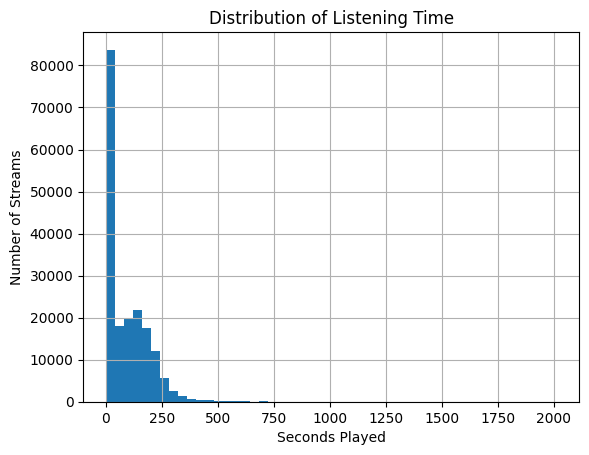

In [21]:
import matplotlib.pyplot as plt

cleaned['sec_played'].hist(bins=50)

plt.title('Distribution of Listening Time')
plt.xlabel('Seconds Played')
plt.ylabel('Number of Streams')
plt.show()
#wow, over 80,000 sreams have a 0 second play time
# minimum threshold to count as a "real" listen: 30 seconds as this is industry standard 
min_threshold = 30 #30 seconds

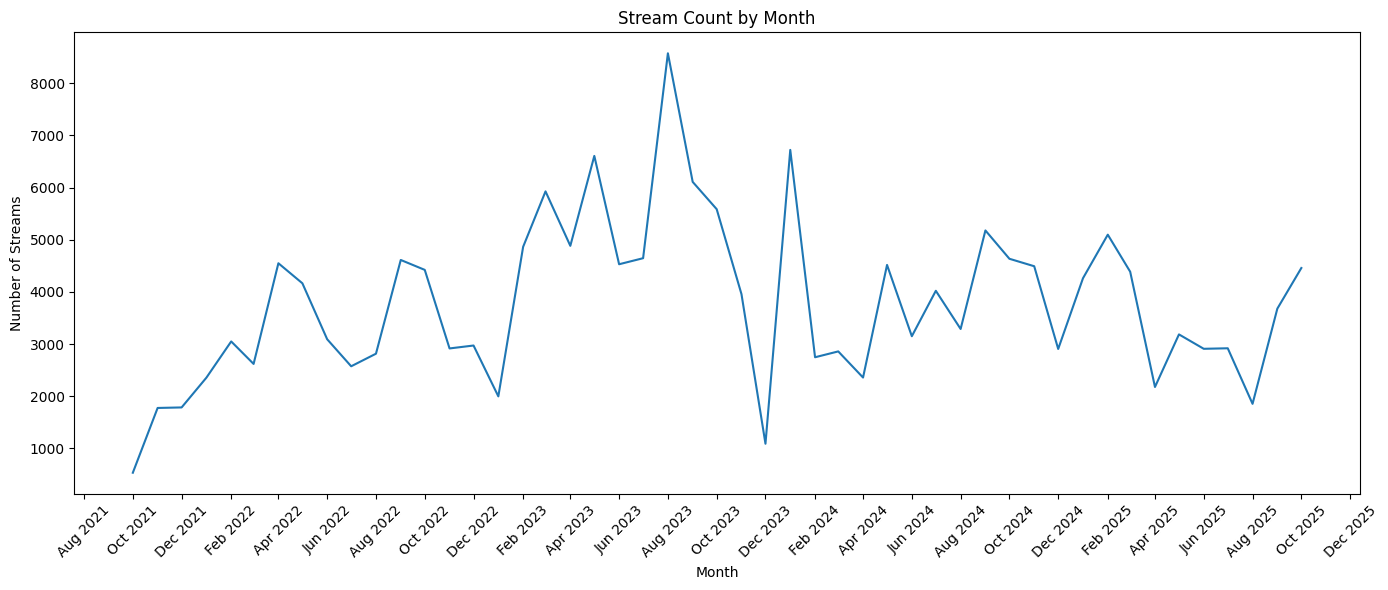

In [22]:
import matplotlib.dates as mdates


monthly_streams = (
    cleaned
    .set_index('date') #change the index to date 
    .resample('MS') #aggregate to month + start of month 
    .size() #get counts of rows for each resample 
)

plt.figure(figsize=(14, 6)) #create blank chart width 14 hieght 6 
plt.plot(
    monthly_streams.index, #x axis becomes resampled months
    monthly_streams.values # y axis becoomes values
) #what other attributes can be derived

plt.title('Stream Count by Month')
plt.xlabel('Month')
plt.ylabel('Number of Streams')

# Get the current plot, access its x-axis, and tell it how to display the date labels
# gca stands for "get current axis"
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

# Show a label every 3 months ..locator answers Where should labels appear?
plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

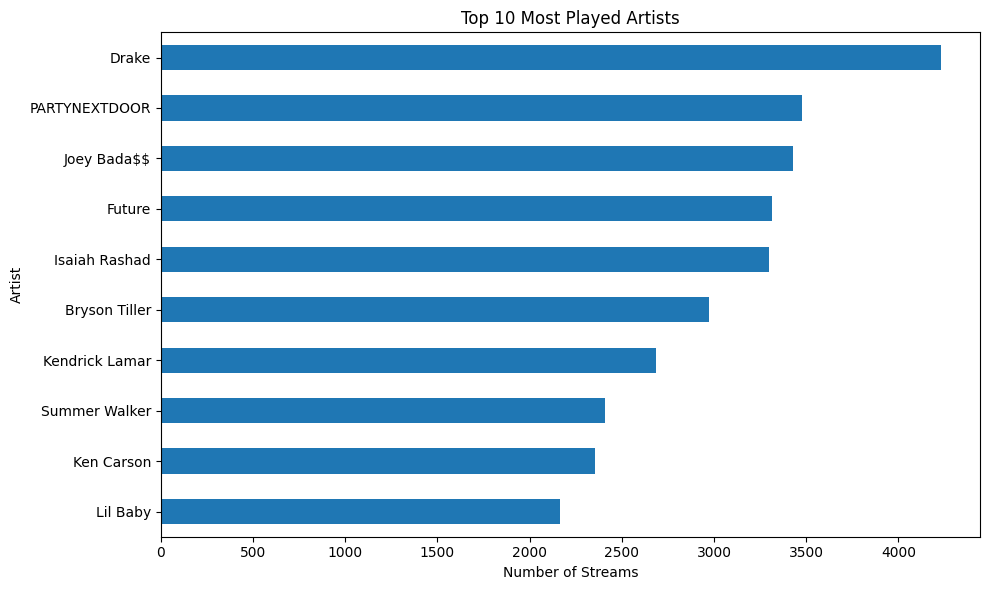

In [23]:
top_artists = cleaned['master_metadata_album_artist_name'].value_counts().head(10)
top_artists.index = top_artists.index.str.replace('$', r'\$', regex=False)


plt.figure(figsize=(10, 6))
top_artists.sort_values().plot(kind='barh')
plt.title('Top 10 Most Played Artists')
plt.xlabel('Number of Streams')
plt.ylabel('Artist')
plt.tight_layout()
plt.show()



In [24]:
cleaned.to_parquet('spotify_cleaned.parquet', index=False)


# Phase 3 - SQL Analysis

In [25]:
import duckdb

con = duckdb.connect('spotify.duckdb')
con.sql("CREATE OR REPLACE TABLE streams AS SELECT * FROM 'spotify_cleaned.parquet'")